# Loss as a function of $\theta$, after every observation

Yes: these figures evaluate the inverse loss directly over the two-dimensional parameter vector $\theta=(\theta_1,\theta_2)$, rather than plotting loss only against epoch number.

For the first $t$ demonstrations, the suboptimality loss is

$$L_t^{SL}(\theta)=\frac1t\sum_{i=1}^t\left[F_\theta(s_i,x_i)-\min_{x\in X(s_i)}F_\theta(s_i,x)\right].$$

The augmented loss is

$$L_t^{ASL}(\theta)=\frac1t\sum_{i=1}^t\max_{x\in X(s_i)}\left[F_\theta(s_i,x_i)-F_\theta(s_i,x)+\Delta(x_i,x)\right].$$

Each column below is a new time step. The landscapes therefore show exactly how new data changes the loss over parameter space.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import invoptlab as io
from invoptlab.losses import evaluate_losses
from invoptlab.metrics import evaluate_predictions

SEED = 42
OBSERVATIONS = 6
ALTERNATIVES = 4
NOISE_PROBABILITY = 0.25
PREFIX_EPOCHS = 15
GRID_RESOLUTION = 17
print('Small settings:', OBSERVATIONS, 'observations,', PREFIX_EPOCHS, 'epochs per prefix,', GRID_RESOLUTION, 'x', GRID_RESOLUTION, 'grid')

Small settings: 6 observations, 15 epochs per prefix, 17 x 17 grid


## Generate a small noisy experiment

The parameter is restricted to the unit disk, so points outside the circle are intentionally blank. Two of the six demonstrations are corrupted for this fixed seed.

In [2]:
problem, dataset, theta_true = io.random_choice_experiment(
    parameter_dimension=2, observations=OBSERVATIONS, alternatives=ALTERNATIVES,
    noise_model=io.RandomFeasibleNoise(NOISE_PROBABILITY), seed=SEED,
)
changed_steps = [i + 1 for i, obs in enumerate(dataset) if obs.noise.get('changed', False)]
print('true theta:', np.round(theta_true, 4))
print('corrupted observation steps:', changed_steps)

true theta: [0.9951 0.0991]
corrupted observation steps: [2, 5]


## Fit on every prefix and evaluate every point in parameter space

At time $t$, only observations $1,\ldots,t$ are used. Both estimators are deliberately short so the example remains fast.

In [3]:
losses = {'SL': io.SuboptimalityLoss(), 'ASL': io.AugmentedSuboptimalityLoss()}
coordinates = np.linspace(-1.0, 1.0, GRID_RESOLUTION)
xx, yy = np.meshgrid(coordinates, coordinates)
landscapes = {name: [] for name in losses}
estimates = {name: [] for name in losses}
time_rows = []

def evaluate_grid(loss, prefix):
    values = np.full_like(xx, np.nan, dtype=float)
    for row in range(GRID_RESOLUTION):
        for column in range(GRID_RESOLUTION):
            theta = np.array([xx[row, column], yy[row, column]])
            if problem.parameter_space.contains(theta):
                per_observation, _, _ = evaluate_losses(loss, problem, theta, prefix.observations)
                values[row, column] = np.mean(per_observation)
    return values

for step in range(1, OBSERVATIONS + 1):
    prefix = dataset[:step]
    for name, loss in losses.items():
        estimator = io.ProjectedSubgradientEstimator(
            loss=loss, epochs=PREFIX_EPOCHS, learning_rate=0.22,
            regularization=1e-3, record_every=5, seed=SEED,
        ).fit(problem, prefix)
        theta_hat = estimator.theta_.copy()
        estimates[name].append(theta_hat)
        landscapes[name].append(evaluate_grid(loss, prefix))
        _, _, metrics = evaluate_predictions(problem, prefix, theta_hat)
        time_rows.append({
            'step': step, 'loss': name,
            'theta_1': theta_hat[0], 'theta_2': theta_hat[1],
            'mean true regret': metrics.get('mean_true_regret'),
            'clean accuracy': metrics.get('clean_decision_accuracy'),
            'loss at estimate': float(np.mean(evaluate_losses(loss, problem, theta_hat, prefix.observations)[0])),
        })
print('Finished all prefix fits and theta grids.')

Finished all prefix fits and theta grids.


## SL and ASL loss landscapes at every time step

Rows are loss definitions; columns are time steps. The green cross is the true parameter and the white circle is the estimate trained on that prefix. Red column titles mark corrupted demonstrations. A darker region means a smaller loss.

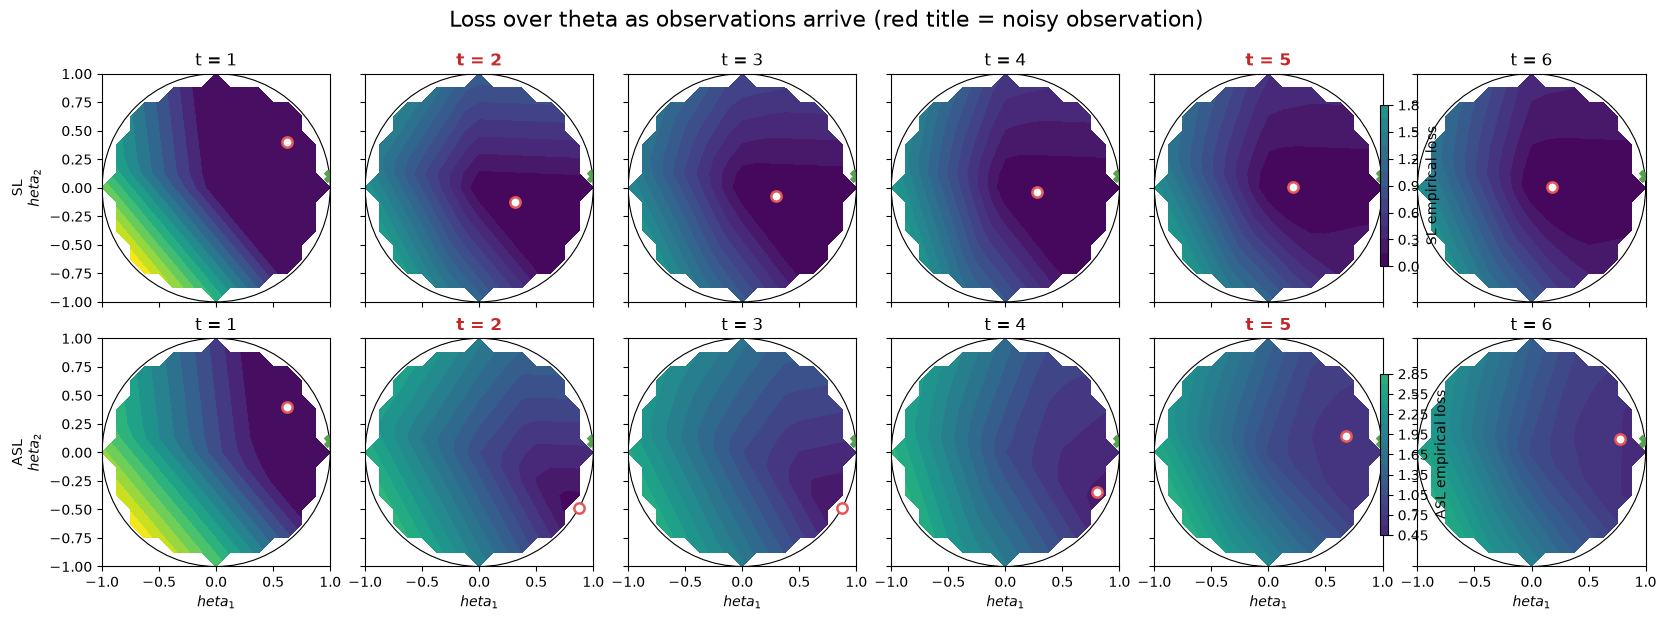

In [4]:
figure, axes = plt.subplots(2, OBSERVATIONS, figsize=(3.25 * OBSERVATIONS, 6.4), sharex=True, sharey=True)
for row, name in enumerate(['SL', 'ASL']):
    finite = np.concatenate([z[np.isfinite(z)] for z in landscapes[name]])
    normalizer = Normalize(vmin=float(finite.min()), vmax=float(finite.max()) or 1.0)
    for column in range(OBSERVATIONS):
        ax = axes[row, column]
        contour = ax.contourf(xx, yy, landscapes[name][column], levels=14, cmap='viridis', norm=normalizer)
        boundary = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=0.8)
        ax.add_patch(boundary)
        estimate = estimates[name][column]
        ax.scatter(*theta_true, color='#54A24B', marker='X', s=70, label='true theta')
        ax.scatter(*estimate, facecolor='white', edgecolor='#E45756', linewidth=1.8, s=55, label='estimate')
        title_color = '#C62828' if column + 1 in changed_steps else 'black'
        ax.set_title(f't = {column + 1}', color=title_color, fontweight='bold' if column + 1 in changed_steps else 'normal')
        ax.set_aspect('equal')
        if column == 0:
            ax.set_ylabel(f'{name}\n$\theta_2$')
        if row == 1:
            ax.set_xlabel('$\theta_1$')
    figure.colorbar(contour, ax=axes[row, :], shrink=0.72, pad=0.01, label=f'{name} empirical loss')
figure.suptitle('Loss over theta as observations arrive (red title = noisy observation)', fontsize=16)
figure.subplots_adjust(top=0.88, wspace=0.12, hspace=0.16, right=0.92)
plt.show()

## Final losses as 3D surfaces over $\theta$

These are the same final-column values shown as height. The vertical coordinate is loss, while the horizontal coordinates are $\theta_1$ and $\theta_2$.

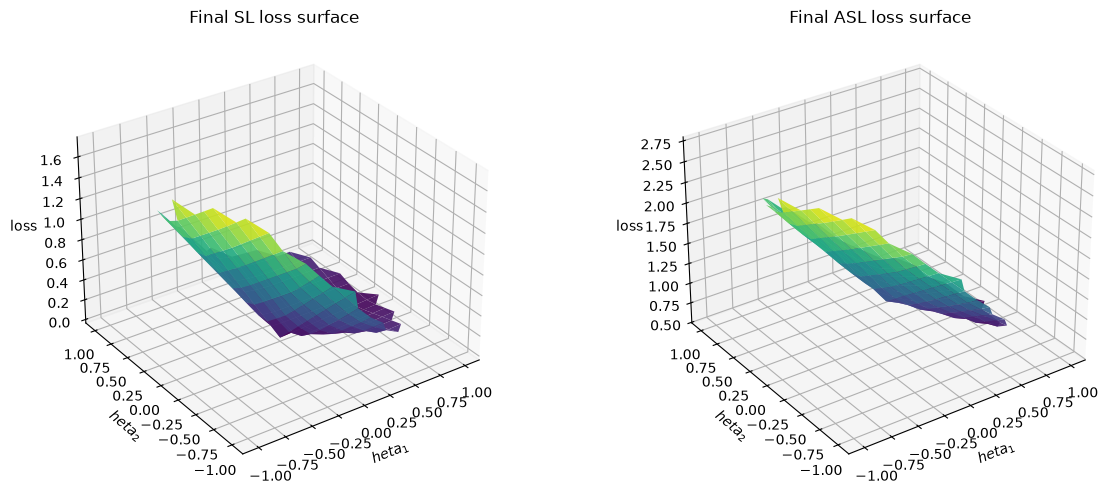

In [5]:
surface_figure = plt.figure(figsize=(13, 5))
for index, name in enumerate(['SL', 'ASL'], start=1):
    ax = surface_figure.add_subplot(1, 2, index, projection='3d')
    ax.plot_surface(xx, yy, landscapes[name][-1], cmap='viridis', edgecolor='none', alpha=0.92)
    ax.set(xlabel='$\theta_1$', ylabel='$\theta_2$', zlabel='loss', title=f'Final {name} loss surface')
    ax.view_init(elev=30, azim=-125)
surface_figure.tight_layout()
plt.show()

## How estimates and performance move with time

The parameter paths live in the same $\theta$ space as the landscapes. The other panels show loss at the learned parameter, true regret, and clean-decision accuracy after each prefix.

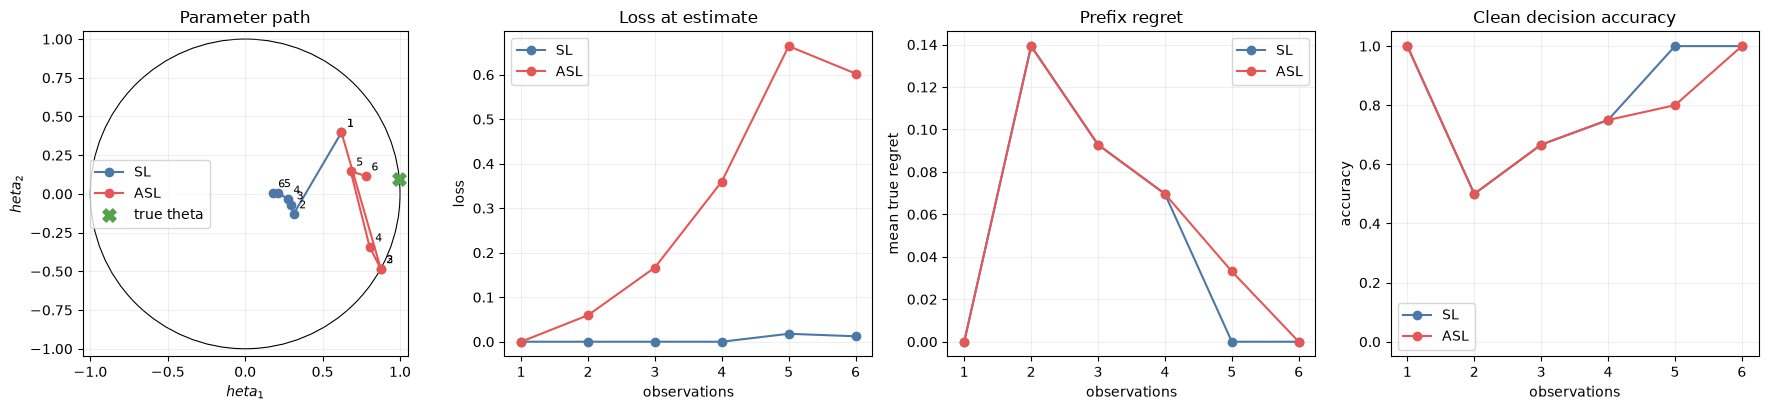

,step,loss,theta_1,theta_2,mean true regret,clean accuracy,loss at estimate
0,1,SL,0.6217,0.3970,0.0000,1.0000,0.0000
1,1,ASL,0.6217,0.3970,0.0000,1.0000,0.0000
2,2,SL,0.3132,-0.1289,0.1393,0.5000,0.0000
3,2,ASL,0.8756,-0.4830,0.1393,0.5000,0.0595
4,3,SL,0.2960,-0.0717,0.0929,0.6667,0.0000
5,3,ASL,0.8754,-0.4833,0.0929,0.6667,0.1667
6,4,SL,0.2753,-0.0347,0.0696,0.7500,0.0000
7,4,ASL,0.8038,-0.3430,0.0696,0.7500,0.3599
8,5,SL,0.2150,0.0084,0.0000,1.0000,0.0178
9,5,ASL,0.6812,0.1471,0.0331,0.8000,0.6641


In [6]:
time_frame = pd.DataFrame(time_rows)
movement_figure, axes = plt.subplots(1, 4, figsize=(18, 4.2))
colors = {'SL': '#4C78A8', 'ASL': '#E45756'}
for name in ['SL', 'ASL']:
    path = np.vstack(estimates[name])
    axes[0].plot(path[:, 0], path[:, 1], marker='o', color=colors[name], label=name)
    for step, point in enumerate(path, start=1):
        axes[0].annotate(str(step), point, xytext=(4, 4), textcoords='offset points', fontsize=8)
    subset = time_frame[time_frame['loss'] == name]
    axes[1].plot(subset['step'], subset['loss at estimate'], marker='o', color=colors[name], label=name)
    axes[2].plot(subset['step'], subset['mean true regret'], marker='o', color=colors[name], label=name)
    axes[3].plot(subset['step'], subset['clean accuracy'], marker='o', color=colors[name], label=name)
axes[0].add_patch(plt.Circle((0, 0), 1, fill=False, color='black', linewidth=0.8))
axes[0].scatter(*theta_true, marker='X', s=90, color='#54A24B', label='true theta')
axes[0].set(xlabel='$\theta_1$', ylabel='$\theta_2$', title='Parameter path', xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), aspect='equal')
axes[1].set(xlabel='observations', ylabel='loss', title='Loss at estimate')
axes[2].set(xlabel='observations', ylabel='mean true regret', title='Prefix regret')
axes[3].set(xlabel='observations', ylabel='accuracy', title='Clean decision accuracy', ylim=(-0.05, 1.05))
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend()
movement_figure.tight_layout()
plt.show()
display(time_frame.round(4))

## Interpretation

- The landscape is piecewise linear because the objective is linear in $\theta$ and the forward decision is selected from a finite set.
- Adding an observation adds another loss term, changing the location and shape of low-loss regions.
- SL can have broad zero-loss regions when many parameter vectors rationalize the observations.
- ASL adds a decision-distance margin, so it generally has a more informative landscape even when ordinary suboptimality is zero.
- Red time labels identify exactly when a corrupted demonstration enters the empirical loss.